In [1]:
import pytangram as tg
import random
import math
import matplotlib.pyplot as plt

In [ ]:
class NeuralNetworkParser:
    @staticmethod
    def parse(architecture: str, activation: str = "sigmoid") -> type[tg.Object]:
        layer_sizes = [int(x) for x in architecture.split("-")]
        n_layers = len(layer_sizes)
        if n_layers < 2: raise ValueError("Architecture must have at least 2 layers")

        layer_names = [f"L{i}" for i in range(n_layers)]
        activation_vars = {}
        for li, sz in enumerate(layer_sizes):
            for ni in range(sz):
                activation_vars[f"a_{li}_{ni}"] = tg.var(0, max=10)

        weight_keys = []
        for l in range(n_layers - 1):
            fn, tn = layer_names[l], layer_names[l+1]
            for i in range(layer_sizes[l]):
                for j in range(layer_sizes[l+1]):
                    weight_keys.append((fn, i, tn, j))

        cap = {"sizes": list(layer_sizes), "names": list(layer_names), "wkeys": list(weight_keys), "n": n_layers}
        namespace = {"__module__": __name__}
        for k, v in activation_vars.items(): namespace[k] = v

        def __init__(self, lr=0.1, activation="sigmoid"):
            self._w = {k: random.uniform(-1.0, 1.0) for k in cap["wkeys"]}
            self._b = {ln: [0.0]*sz for ln, sz in zip(cap["names"], cap["sizes"])}
            self._lr = lr
            self._sizes = cap["sizes"]; self._names = cap["names"]
            self._wkeys = cap["wkeys"]; self._n = cap["n"]
            self._activation = activation
            self._input = None; self._target = None; self._last_act = None
        namespace["__init__"] = __init__

        def set_input(self, val): self._input = val
        namespace["set_input"] = set_input

        def set_target(self, tgt):
            if len(tgt) != self._sizes[-1]: raise ValueError("Target mismatch")
            self._target = tgt
        namespace["set_target"] = set_target

        @staticmethod
        def _sig(x):
            if x < -500: return 0.0
            if x > 500: return 1.0
            return 1.0 / (1.0 + math.exp(-x))

        @staticmethod
        def _relu(x): return max(0.0, x)

        @staticmethod
        def _sig_d(y): return y * (1.0 - y)

        @staticmethod
        def _relu_d(x): return 1.0 if x > 0.0 else 0.0

        def _activate(self, x):
            return self._relu(x) if self._activation == "relu" else self._sig(x)

        def _activate_d(self, x):
            return self._relu_d(x) if self._activation == "relu" else self._sig_d(self._activate(x))

        namespace["_sig"] = _sig
        namespace["_relu"] = _relu
        namespace["_sig_d"] = _sig_d
        namespace["_relu_d"] = _relu_d
        namespace["_activate"] = _activate
        namespace["_activate_d"] = _activate_d

        def _forward(self, x):
            if isinstance(x, (int, float)): x = [float(x)]
            else: x = list(x)
            act = {self._names[0]: x}
            for li in range(1, self._n):
                ln = self._names[li]; pln = self._names[li-1]; prev = act[pln]
                raw = []
                for j in range(self._sizes[li]):
                    s = self._b[ln][j]
                    for i in range(self._sizes[li-1]):
                        s += self._w[(pln, i, ln, j)] * prev[i]
                    raw.append(self._activate(s))
                act[ln] = raw
            return act
        namespace["_forward"] = _forward

        def compute(self) -> dict[str, float]:
            if self._input is None: raise ValueError("Input not set")
            self._last_act = self._forward(self._input)
            res = {}
            for li, ln in enumerate(self._names):
                for ni, v in enumerate(self._last_act[ln]):
                    res[f"a_{li}_{ni}"] = v
            return res
        namespace["compute"] = compute

        def _compute_gradients(self):
            if self._target is None: raise ValueError("Target not set")
            if self._last_act is None: raise ValueError("Run compute() first")
            act = self._last_act; tgt = self._target; out_ln = self._names[-1]; out = act[out_ln]
            loss = sum((y-t)**2 for y,t in zip(out,tgt)) / len(tgt)
            deltas = {}
            for j, (y,t) in enumerate(zip(out,tgt)):
                deltas[(out_ln, j)] = 2*(y-t)/len(tgt) * self._activate_d(y)
            for li in range(self._n-2, 0, -1):
                ln = self._names[li]; nln = self._names[li+1]
                for i in range(self._sizes[li]):
                    ds = sum(self._w[(ln,i,nln,j)] * deltas[(nln,j)] for j in range(self._sizes[li+1]))
                    deltas[(ln, i)] = self._activate_d(act[ln][i]) * ds
            wg, bg = {}, {}
            for pln, i, ln, j in self._wkeys:
                wg[(pln,i,ln,j)] = act[pln][i] * deltas[(ln,j)]
            for li in range(1, self._n):
                ln = self._names[li]
                for j in range(self._sizes[li]):
                    bg[(ln,j)] = deltas[(ln,j)]
            return wg, bg, loss
        namespace["_compute_gradients"] = _compute_gradients

        def train(self, dataset, epochs=100, verbose=10):
            n = len(dataset)
            if n == 0: raise ValueError("Empty dataset")
            hist = []; lr = self._lr
            for ep in range(epochs):
                wga = {k:0.0 for k in self._wkeys}
                bga = {(ln,j):0.0 for ln in self._names for j in range(self._sizes[self._names.index(ln)])}
                el = 0.0
                for x, y in dataset:
                    self._input = x; self._target = y
                    self._last_act = self._forward(x)
                    wg, bg, l = self._compute_gradients()
                    el += l
                    for k,g in wg.items(): wga[k] += g
                    for k,g in bg.items(): bga[k] += g
                for k in wga: self._w[k] -= lr * (wga[k]/n)
                for k in bga: self._b[k[0]][k[1]] -= lr * (bga[k]/n)
                avg = el / n
                hist.append(avg)
                if verbose > 0 and ep % verbose == 0: print(f"Epoch {ep:4d}/{epochs}: avg_loss = {avg:.6f}")
            if verbose > 0 and epochs % verbose != 0: print(f"Epoch {epochs:4d}/{epochs}: avg_loss = {hist[-1]:.6f}")
            return hist
        namespace["train"] = train

        class_name = f"Network_{architecture.replace('-', 'x')}"
        Network = type(class_name, (tg.Object,), namespace)
        return Network

In [7]:
class NeuralNetworkParser:
    @staticmethod
    def parse(architecture: str, activation: str = "sigmoid") -> type[tg.Object]:
        layer_sizes = [int(x) for x in architecture.split("-")]
        n_layers = len(layer_sizes)
        if n_layers < 2: raise ValueError("Architecture must have at least 2 layers")

        layer_names = [f"L{i}" for i in range(n_layers)]
        activation_vars = {}
        for li, sz in enumerate(layer_sizes):
            for ni in range(sz):
                activation_vars[f"a_{li}_{ni}"] = tg.var(0, max=10)

        weight_keys = []
        for l in range(n_layers - 1):
            fn, tn = layer_names[l], layer_names[l+1]
            for i in range(layer_sizes[l]):
                for j in range(layer_sizes[l+1]):
                    weight_keys.append((fn, i, tn, j))

        cap = {"sizes": list(layer_sizes), "names": list(layer_names), "wkeys": list(weight_keys), "n": n_layers}
        namespace = {"__module__": __name__}
        for k, v in activation_vars.items(): namespace[k] = v

        def __init__(self, lr=0.1, activation="sigmoid"):
            self._w = {k: random.uniform(-1.0, 1.0) for k in cap["wkeys"]}
            self._b = {ln: [0.0]*sz for ln, sz in zip(cap["names"], cap["sizes"])}
            self._lr = lr
            self._sizes = cap["sizes"]; self._names = cap["names"]
            self._wkeys = cap["wkeys"]; self._n = cap["n"]
            self._activation = activation
            self._input = None; self._target = None; self._last_act = None
        namespace["__init__"] = __init__

        def set_input(self, val): self._input = val
        namespace["set_input"] = set_input

        def set_target(self, tgt):
            if len(tgt) != self._sizes[-1]: raise ValueError("Target mismatch")
            self._target = tgt
        namespace["set_target"] = set_target

        @staticmethod
        def _sig(x):
            if x < -500: return 0.0
            if x > 500: return 1.0
            return 1.0 / (1.0 + math.exp(-x))

        @staticmethod
        def _relu(x): return max(0.0, x)

        @staticmethod
        def _sig_d(y): return y * (1.0 - y)

        @staticmethod
        def _relu_d(x): return 1.0 if x > 0.0 else 0.0

        def _activate(self, x):
            return self._relu(x) if self._activation == "relu" else self._sig(x)

        def _activate_d(self, x):
            return self._relu_d(x) if self._activation == "relu" else self._sig_d(self._activate(x))

        namespace["_sig"] = _sig
        namespace["_relu"] = _relu
        namespace["_sig_d"] = _sig_d
        namespace["_relu_d"] = _relu_d
        namespace["_activate"] = _activate
        namespace["_activate_d"] = _activate_d

        def _forward(self, x):
            if isinstance(x, (int, float)): x = [float(x)]
            else: x = list(x)
            act = {self._names[0]: x}
            for li in range(1, self._n):
                ln = self._names[li]; pln = self._names[li-1]; prev = act[pln]
                raw = []
                for j in range(self._sizes[li]):
                    s = self._b[ln][j]
                    for i in range(self._sizes[li-1]):
                        s += self._w[(pln, i, ln, j)] * prev[i]
                    raw.append(self._activate(s))
                act[ln] = raw
            return act
        namespace["_forward"] = _forward

        def compute(self) -> dict[str, float]:
            if self._input is None: raise ValueError("Input not set")
            self._last_act = self._forward(self._input)
            res = {}
            for li, ln in enumerate(self._names):
                for ni, v in enumerate(self._last_act[ln]):
                    res[f"a_{li}_{ni}"] = v
            return res
        namespace["compute"] = compute

        def _compute_gradients(self):
            if self._target is None: raise ValueError("Target not set")
            if self._last_act is None: raise ValueError("Run compute() first")
            act = self._last_act; tgt = self._target; out_ln = self._names[-1]; out = act[out_ln]
            loss = sum((y-t)**2 for y,t in zip(out,tgt)) / len(tgt)
            deltas = {}
            for j, (y,t) in enumerate(zip(out,tgt)):
                deltas[(out_ln, j)] = 2*(y-t)/len(tgt) * self._activate_d(y)
            for li in range(self._n-2, 0, -1):
                ln = self._names[li]; nln = self._names[li+1]
                for i in range(self._sizes[li]):
                    ds = sum(self._w[(ln,i,nln,j)] * deltas[(nln,j)] for j in range(self._sizes[li+1]))
                    deltas[(ln, i)] = self._activate_d(act[ln][i]) * ds
            wg, bg = {}, {}
            for pln, i, ln, j in self._wkeys:
                wg[(pln,i,ln,j)] = act[pln][i] * deltas[(ln,j)]
            for li in range(1, self._n):
                ln = self._names[li]
                for j in range(self._sizes[li]):
                    bg[(ln,j)] = deltas[(ln,j)]
            return wg, bg, loss
        namespace["_compute_gradients"] = _compute_gradients

        def train(self, dataset, epochs=100, verbose=10):
            n = len(dataset)
            if n == 0: raise ValueError("Empty dataset")
            hist = []; lr = self._lr
            for ep in range(epochs):
                wga = {k:0.0 for k in self._wkeys}
                bga = {(ln,j):0.0 for ln in self._names for j in range(self._sizes[self._names.index(ln)])}
                el = 0.0
                for x, y in dataset:
                    self._input = x; self._target = y
                    self._last_act = self._forward(x)
                    wg, bg, l = self._compute_gradients()
                    el += l
                    for k,g in wg.items(): wga[k] += g
                    for k,g in bg.items(): bga[k] += g
                for k in wga: self._w[k] -= lr * (wga[k]/n)
                for k in bga: self._b[k[0]][k[1]] -= lr * (bga[k]/n)
                avg = el / n
                hist.append(avg)
                if verbose > 0 and ep % verbose == 0: print(f"Epoch {ep:4d}/{epochs}: avg_loss = {avg:.6f}")
            if verbose > 0 and epochs % verbose != 0: print(f"Epoch {epochs:4d}/{epochs}: avg_loss = {hist[-1]:.6f}")
            return hist
        namespace["train"] = train

        class_name = f"Network_{architecture.replace('-', 'x')}"
        Network = type(class_name, (tg.Object,), namespace)
        return Network

In [ ]:
NetworkClass = NeuralNetworkParser.parse("2-4-10-1")
nn = NetworkClass(lr=0.5)

def in_circle(x: float, y: float, r: float = 0.75) -> int:
    return 0 if (x * x + y * y) <= (r * r) else 1

dataset = []

# Build a 100x100 grid, normalized to [-1, 1]
for i in range(100):
    for j in range(100):
        x = (i / 99.0) * 2.0 - 1.0
        y = (j / 99.0) * 2.0 - 1.0
        label = float(in_circle(x, y, r=0.75))

        # IMPORTANT: each item must be (input_list, target_list)
        dataset.append(([x, y], [label]))

history = nn.train(dataset, epochs=1000, verbose=100)
print("Final loss:", history[-1])

Epoch    0/1000: avg_loss = 0.250575


In [ ]:
correct = 0

for x, y in dataset:
    nn.set_input(x)
    out = nn.compute()["a_3_0"]   
    pred = 1.0 if out >= 0.5 else 0.0
    if pred == y[0]:
        correct += 1

acc = correct / len(dataset)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9651


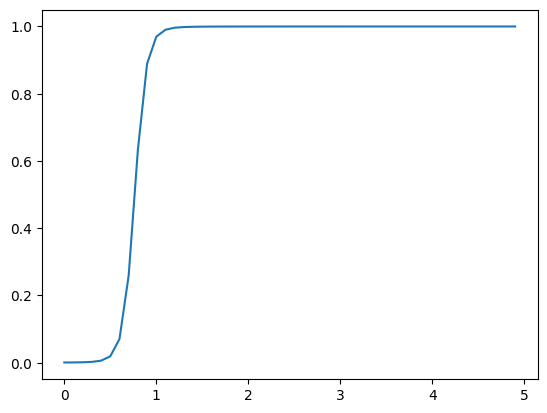

In [ ]:
x = [i/10 for i in range(50)]
y = []
for i in x:
    nn.set_input([0,i])
    y.append(nn.compute()['a_3_0'])


plt.plot(x,y)
plt.show()

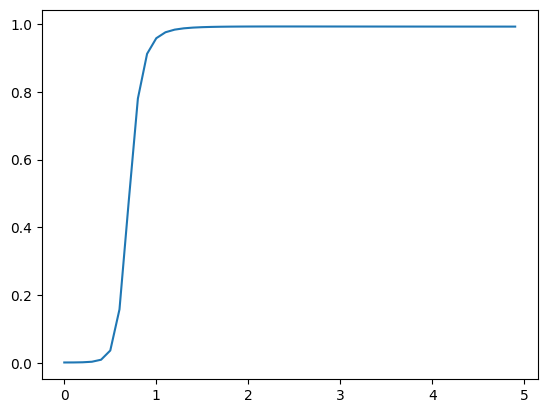

In [ ]:
x = [i/10 for i in range(50)]
y = []
for i in x:
    nn.set_input([i,0])
    y.append(nn.compute()['a_3_0'])


plt.plot(x,y)
plt.show()

### Usando CLAPP


In [ ]:
def attach_clapp_methods(NetworkClass):
    if hasattr(NetworkClass, "train_clapp"):
        return NetworkClass

    def _softplus(x: float) -> float:
        if x > 30.0: return x
        if x < -30.0: return math.exp(x)
        return math.log1p(math.exp(x))

    def _logistic(x: float) -> float:
        if x >= 0.0:
            e = math.exp(-x); return 1.0 / (1.0 + e)
        e = math.exp(x); return e / (1.0 + e)

    def _clapp_step(self, x_anchor, x_context, x_negative, lambda_b, beta_b, direct_feedback):
        act_p = self._forward(x_anchor)
        act_c = self._forward(x_context)
        act_n = self._forward(x_negative)

        total_loss = 0.0
        wg = {k:0.0 for k in self._wkeys}
        bg = {(ln,j):0.0 for ln in self._names for j in range(self._sizes[self._names.index(ln)])}
        bg_b = {}

        for li in range(1, self._n):
            ln = self._names[li]; pln = self._names[li-1]
            z_p = act_p[ln]; z_n = act_n[ln]
            c_vec = act_c[self._names[-1]] if direct_feedback else act_c[ln]
            B = self._clapp_B[ln]

            u = [sum(B[j][k] * c_vec[k] for k in range(len(c_vec))) for j in range(len(z_p))]
            s_p = sum(z_p[j]*u[j] for j in range(len(z_p)))
            s_n = sum(z_n[j]*u[j] for j in range(len(z_n)))

            loss_l = _softplus(-s_p) + _softplus(s_n)
            reg = sum(v*v for row in B for v in row)
            loss_l += lambda_b * reg
            total_loss += loss_l

            g_p = -_logistic(-s_p); g_n = _logistic(s_n)

            for j in range(len(B)):
                for k in range(len(c_vec)):
                    bg_b[(ln,j,k)] = g_p*z_p[j]*c_vec[k] + g_n*z_n[j]*c_vec[k] + 2.0*lambda_b*B[j][k]

            # Use _activate_d for ReLU/Sigmoid support
            dp = [self._activate_d(v) for v in z_p]
            dn = [self._activate_d(v) for v in z_n]
            zp_prev = act_p[pln]; zn_prev = act_n[pln]

            for i in range(self._sizes[li-1]):
                for j in range(self._sizes[li]):
                    wg[(pln,i,ln,j)] += g_p*u[j]*dp[j]*zp_prev[i] + g_n*u[j]*dn[j]*zn_prev[i]

            for j in range(self._sizes[li]):
                bg[(ln,j)] += g_p*u[j]*dp[j] + g_n*u[j]*dn[j]

        # ONLINE UPDATE (faithful to paper: update immediately)
        for k in wg: self._w[k] -= self._lr * wg[k]
        for k in bg: self._b[k[0]][k[1]] -= self._lr * bg[k]
        for (ln,j,k), g in bg_b.items():
            self._clapp_B[ln][j][k] -= beta_b * g

        return total_loss

    def train_clapp(self, triplets, epochs=100, verbose=10, lambda_b=1e-3, beta_b=None, direct_feedback=False, shuffle=True):
        """Online CLAPP training (update per sample)."""
        n = len(triplets)
        if n == 0: raise ValueError("Triplet list is empty.")
        if beta_b is None: beta_b = self._lr * 10.0  # Paper: B evolves much faster than W

        if not hasattr(self, "_clapp_B"):
            self._clapp_B = {}
        for li in range(1, self._n):
            ln = self._names[li]; ctx_dim = self._sizes[-1] if direct_feedback else self._sizes[li]
            self._clapp_B[ln] = [[random.uniform(-0.1, 0.1) for _ in range(ctx_dim)] for _ in range(self._sizes[li])]

        hist = []
        for ep in range(epochs):
            if shuffle: random.shuffle(triplets)
            el = 0.0

            for xa, xc, xn in triplets:
                l = self._clapp_step(xa, xc, xn, lambda_b, beta_b, direct_feedback)
                el += l

            avg = el / n
            hist.append(avg)
            if verbose > 0 and ep % verbose == 0: print(f"Epoch {ep:4d}/{epochs}: clapp_loss = {avg:.6f}")

        if verbose > 0 and epochs % verbose != 0: print(f"Epoch {epochs:4d}/{epochs}: clapp_loss = {hist[-1]:.6f}")
        return hist

    def get_clapp_projections(self):
        if not hasattr(self, "_clapp_B"): return {}
        return {k: [row[:] for row in v] for k, v in self._clapp_B.items()}

    NetworkClass._softplus = staticmethod(_softplus)
    NetworkClass._logistic = staticmethod(_logistic)
    NetworkClass._clapp_step = _clapp_step
    NetworkClass.train_clapp = train_clapp
    NetworkClass.get_clapp_projections = get_clapp_projections
    return NetworkClass


def build_clapp_triplets_from_labeled(dataset):
    by_label = {}
    for x, y in dataset:
        lbl = tuple(y); by_label.setdefault(lbl, []).append(list(x))
    labels = list(by_label.keys()); triplets = []
    for x, y in dataset:
        lbl = tuple(y)
        x_ctx = random.choice(by_label[lbl])
        neg_lbl = random.choice([k for k in labels if k != lbl]) if len(labels) > 1 else lbl
        x_neg = random.choice(by_label[neg_lbl])
        triplets.append((list(x), list(x_ctx), list(x_neg)))
    return triplets

In [ ]:
# Exemplo de uso CLAPP no mesmo objeto da rede
NetworkClass = NeuralNetworkParser.parse("1-2-2-1")
NetworkClass = attach_clapp_methods(NetworkClass)
nnc = NetworkClass(lr=0.05)

dataset = [
    ([0.0], [0.0]),
    ([0.0], [1.0]),
    ([1.0], [0.0]),
    ([1.0], [1.0]),
]

triplets = build_clapp_triplets_from_labeled(dataset)

history_clapp = nnc.train_clapp(
    triplets,
    epochs=1200,
    verbose=100,
    lambda_b=1e-3,
    beta_b=0.01,
    direct_feedback=False,
)

print("Final CLAPP loss:", history_clapp[-1])

for x, y in dataset:
    nnc.set_input(x)
    out = nnc.compute()["a_3_0"]
    print(f"Input: {x} -> Output: {out:.4f}, Target: {y[0]}")

AttributeError: 'Network_1x2x2x1' object has no attribute '_n'

In [ ]:
NetworkClass = NeuralNetworkParser.parse("2-4-4-1")
nnc = NetworkClass(lr=0.5)

def in_circle(x: float, y: float, r: float = 0.75) -> int:
    return 0 if (x * x + y * y) <= (r * r) else 1

dataset = []

# Build a 100x100 grid, normalized to [-1, 1]
for i in range(100):
    for j in range(100):
        x = (i / 99.0) * 2.0 - 1.0
        y = (j / 99.0) * 2.0 - 1.0
        label = float(in_circle(x, y, r=0.75))

        # IMPORTANT: each item must be (input_list, target_list)
        dataset.append(([x, y], [label]))

history = nnc.train(dataset, epochs=1000, verbose=100)
print("Final loss:", history[-1])

Epoch    0/5000: avg_loss = 0.304897
Epoch  100/5000: avg_loss = 0.245686
Epoch  200/5000: avg_loss = 0.245659
Epoch  300/5000: avg_loss = 0.245631
Epoch  400/5000: avg_loss = 0.245601
Epoch  500/5000: avg_loss = 0.245566
Epoch  600/5000: avg_loss = 0.245525
Epoch  700/5000: avg_loss = 0.245475
Epoch  800/5000: avg_loss = 0.245413
Epoch  900/5000: avg_loss = 0.245336
Epoch 1000/5000: avg_loss = 0.245238
Epoch 1100/5000: avg_loss = 0.245116
Epoch 1200/5000: avg_loss = 0.244962
Epoch 1300/5000: avg_loss = 0.244769
Epoch 1400/5000: avg_loss = 0.244527
Epoch 1500/5000: avg_loss = 0.244228
Epoch 1600/5000: avg_loss = 0.243857
Epoch 1700/5000: avg_loss = 0.243397
Epoch 1800/5000: avg_loss = 0.242827
Epoch 1900/5000: avg_loss = 0.242112
Epoch 2000/5000: avg_loss = 0.241203
Epoch 2100/5000: avg_loss = 0.240027
Epoch 2200/5000: avg_loss = 0.238470
Epoch 2300/5000: avg_loss = 0.236362
Epoch 2400/5000: avg_loss = 0.233442
Epoch 2500/5000: avg_loss = 0.229331
Epoch 2600/5000: avg_loss = 0.223531
E

In [ ]:
correct = 0

for x, y in dataset:
    nnc.set_input(x)
    out = nnc.compute()["a_3_0"]   
    pred = 1.0 if out >= 0.5 else 0.0
    if pred == y[0]:
        correct += 1

acc = correct / len(dataset)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9667


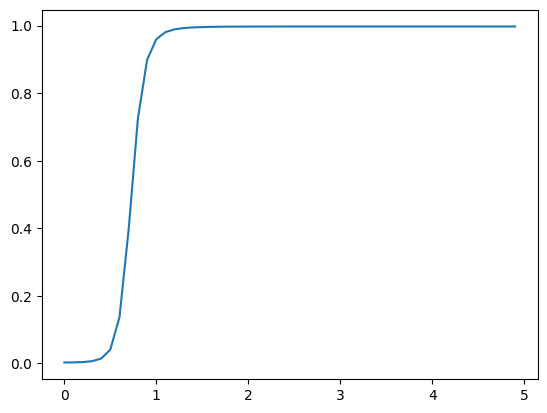

In [ ]:
x = [i/10 for i in range(50)]
y = []
for i in x:
    nnc.set_input([0,i])
    y.append(nnc.compute()['a_3_0'])

import matplotlib.pyplot as plt

plt.plot(x,y)
plt.show()

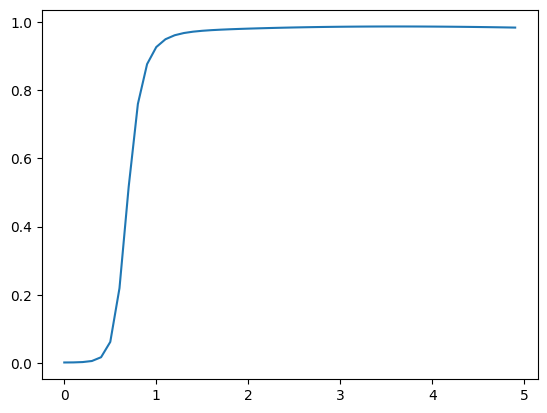

In [ ]:
x = [i/10 for i in range(50)]
y = []
for i in x:
    nn.set_input([i,0])
    y.append(nnc.compute()['a_3_0'])


plt.plot(x,y)
plt.show()

### Usando CLAPP++
No MLP deste notebook, CLAPP++ e usado como a variante com direct feedback (`direct_feedback=True`).

In [ ]:
# Treino CLAPP++ (DFB) no problema do circulo
NetworkClass = NeuralNetworkParser.parse("2-4-10-1")
NetworkClass = attach_clapp_methods(NetworkClass)
nnpp = NetworkClass(lr=0.05)

dataset_pp = []
for i in range(60):
    for j in range(60):
        x = (i / 59.0) * 2.0 - 1.0
        y = (j / 59.0) * 2.0 - 1.0
        label = float(in_circle(x, y, r=0.75))
        dataset_pp.append(([x, y], [label]))

triplets_pp = build_clapp_triplets_from_labeled(dataset_pp)

history_pp = nnpp.train_clapp(
    triplets_pp,
    epochs=1000,
    verbose=50,
    lambda_b=1e-3,
    beta_b=0.01,
    direct_feedback=True,
)

print("Final CLAPP++ loss:", history_pp[-1])

Epoch    0/5000: clapp_loss = 4.159103
Epoch   50/5000: clapp_loss = 4.158728
Epoch  100/5000: clapp_loss = 4.158597
Epoch  150/5000: clapp_loss = 4.158190
Epoch  200/5000: clapp_loss = 4.153288
Epoch  250/5000: clapp_loss = 4.062776
Epoch  300/5000: clapp_loss = 3.418636
Epoch  350/5000: clapp_loss = 3.310751
Epoch  400/5000: clapp_loss = 3.241059
Epoch  450/5000: clapp_loss = 3.262102
Epoch  500/5000: clapp_loss = 3.219270
Epoch  550/5000: clapp_loss = 3.199215
Epoch  600/5000: clapp_loss = 3.199415
Epoch  650/5000: clapp_loss = 3.150011
Epoch  700/5000: clapp_loss = 3.178121
Epoch  750/5000: clapp_loss = 3.129885
Epoch  800/5000: clapp_loss = 3.155420
Epoch  850/5000: clapp_loss = 3.114654
Epoch  900/5000: clapp_loss = 3.134003
Epoch  950/5000: clapp_loss = 3.141627
Epoch 1000/5000: clapp_loss = 3.138736
Epoch 1050/5000: clapp_loss = 3.143621
Epoch 1100/5000: clapp_loss = 3.139136
Epoch 1150/5000: clapp_loss = 3.122402
Epoch 1200/5000: clapp_loss = 3.159508
Epoch 1250/5000: clapp_lo

In [ ]:
correct_pp = 0

for x, y in dataset_pp:
    nnpp.set_input(x)
    out = nnpp.compute()["a_3_0"]
    pred = 1.0 if out >= 0.5 else 0.0
    if pred == y[0]:
        correct_pp += 1

acc_pp = correct_pp / len(dataset_pp)
print(f"CLAPP++ Accuracy: {acc_pp:.4f}")

CLAPP++ Accuracy: 0.5733


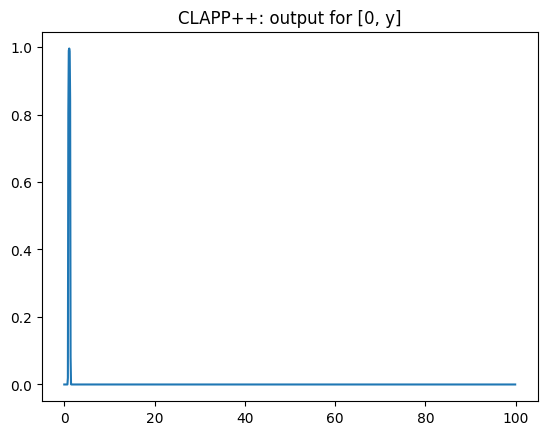

In [ ]:
x = [i / 10 for i in range(1000)]
y = []
for i in x:
    nnpp.set_input([0, i])
    y.append(nnpp.compute()["a_3_0"])

plt.plot(x, y)
plt.title("CLAPP++: output for [0, y]")
plt.show()

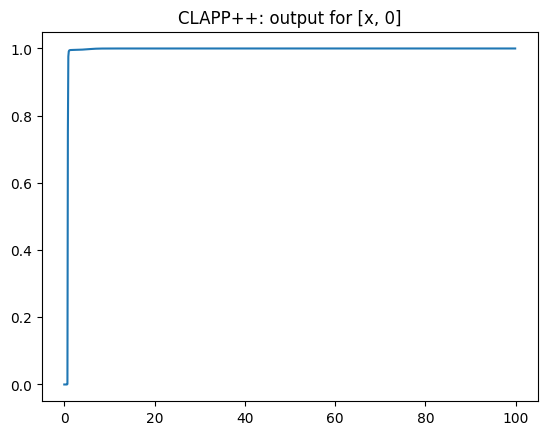

In [ ]:
x = [i / 10 for i in range(1000)]
y = []
for i in x:
    nnpp.set_input([i, 0])
    y.append(nnpp.compute()["a_3_0"])

plt.plot(x, y)
plt.title("CLAPP++: output for [x, 0]")
plt.show()

### Comparação Fiel ao Paper: BP (Batch) vs CLAPP (Online) vs CLAPP++DFB

In [ ]:
def in_circle(x: float, y: float, r: float = 0.75) -> float:
    return 0.0 if (x * x + y * y) <= (r * r) else 1.0

dataset = []
for i in range(100):
    for j in range(100):
        x = (i / 99.0) * 2.0 - 1.0
        y = (j / 99.0) * 2.0 - 1.0
        dataset.append(([x, y], [in_circle(x, y)]))

triplets = build_clapp_triplets_from_labeled(dataset)

In [ ]:
# Paper assumptions: ReLU, Online updates, B faster than W (beta_b >> lr)
ACT = "relu"
N_EPOCHS = 1000
LR = 0.05
V = 200

# BP (Batch)
NetBP = NeuralNetworkParser.parse("2-10-10-1", activation=ACT)
nn_bp = NetBP(lr=LR, activation=ACT)
hist_bp = nn_bp.train(dataset, epochs=N_EPOCHS, verbose=V)

# CLAPP (Online, beta_b = lr * 10)
NetCL = attach_clapp_methods(NeuralNetworkParser.parse("2-10-10-1", activation=ACT))
nn_cl = NetCL(lr=LR, activation=ACT)
hist_cl = nn_cl.train_clapp(triplets, epochs=N_EPOCHS, verbose=V, direct_feedback=False, beta_b=LR*10)

# CLAPP++DFB (Online, beta_b = lr * 10)
NetDF = attach_clapp_methods(NeuralNetworkParser.parse("2-10-10-1", activation=ACT))
nn_df = NetDF(lr=LR, activation=ACT)
hist_df = nn_df.train_clapp(triplets, epochs=N_EPOCHS, verbose=V, direct_feedback=True, beta_b=LR*10)

In [ ]:
def evaluate(net, data):
    c = 0
    for x, y in data:
        net.set_input(x)
        out = net.compute()["a_3_0"]
        pred = 1.0 if out >= 0.5 else 0.0
        if pred == y[0]: c += 1
    return c / len(data)

acc_bp = evaluate(nn_bp, dataset)
acc_cl = evaluate(nn_cl, dataset)
acc_df = evaluate(nn_df, dataset)

print(f"BP Accuracy:    {acc_bp:.4f} (Final Loss: {hist_bp[-1]:.4f})")
print(f"CLAPP Accuracy: {acc_cl:.4f} (Final Loss: {hist_cl[-1]:.4f})")
print(f"CLAPP++DFB Acc: {acc_df:.4f} (Final Loss: {hist_df[-1]:.4f})")

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(hist_bp, label="BP (Batch, ReLU)", linewidth=2)
plt.plot(hist_cl, label="CLAPP (Online, ReLU)", linestyle="--", linewidth=2)
plt.plot(hist_df, label="CLAPP++DFB (Online, ReLU)", linestyle=":-", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Faithful Comparison: BP vs CLAPP vs CLAPP++DFB")
plt.legend()
plt.grid(True)
plt.show()